# Nationality Detection Model

## Objective

The objective of this project is to develop a machine learning system that predicts a person's nationality category and emotion from an uploaded image.
The system follows the requirements of the internship task:

- Predict nationality category from the uploaded image.
- Predict the person's emotion.
- For **Indian** nationality:
  - Predict age
  - Predict dress colour
  - Predict emotion
- For **United States** nationality:
  - Predict age
  - Predict emotion
- For **African** nationality:
  - Predict dress colour
  - Predict emotion
- For other nationality categories:
  - Predict nationality
  - Predict emotion

The final system includes trained CNN models, model comparison, and a Gradio-based graphical user interface.

## Features
- Nationality category classification using CNN
- Emotion classification using CNN
- Age prediction
- Dress colour classification
- CNN vs transfer-learning model comparison
- Accuracy and loss visualization
- Classification report and confusion matrix
- Gradio GUI for image upload and prediction
- Conditional output based on the predicted nationality category

## Problem Statement
The task is to develop a machine learning system that takes a person's image as input and produces the required predictions.

### Required Logic
1. Upload a person's image.
2. Predict the nationality category.
3. Predict the emotion.
4. If the predicted nationality is **Indian**:
   - Predict age.
   - Predict dress colour.
   - Display emotion.
5. If the predicted nationality is **United States**:
   - Predict age.
   - Display emotion.
6. If the predicted nationality is **African**:
   - Predict dress colour.
   - Display emotion.
7. For other nationality categories:
   - Display nationality.
   - Display emotion.

## Dataset Description
### UTKFace Dataset
UTKFace provides face images labelled with age, gender, and ethnicity. Ethnicity labels are remapped onto the four nationality buckets this task requires (Indian, USA, African, Other), and age is used directly. This is the dataset the nationality + age CNN is actually trained on.

### FairFace Dataset
FairFace is a separately collected, more demographically balanced face dataset with its own race labels. It is never used during training - it is held out specifically to test whether the nationality model generalises to faces it has never seen, rather than just memorising patterns from UTKFace.

### FER2013 Dataset
The FER2013 dataset is used for emotion classification.
The model predicts seven emotion classes:
- Angry
- Disgust
- Fear
- Happy
- Sad
- Surprise
- Neutral

### Fashion Product Images Dataset
This dataset contains real clothing product photos labelled with actual colour names. Instead of hand-picking a small palette of RGB values, the colour names used for dress-colour prediction are built directly from this dataset - averaging pixel colours from real labelled photos per colour category. A held-out subset (images not used to build the colour table) is used to check colour-classification accuracy.

## Imports

In [1]:
!pip install -q opencv-python-headless ipywidgets scikit-learn gradio

In [2]:
import os
import colorsys
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

## Dataset Paths

In [3]:
MANUAL_FASHION_ROOT = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset'
MANUAL_UTKFACE_ROOT = '/kaggle/input/datasets/jangedoo/utkface-new'
MANUAL_FER2013_ROOT = '/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv'
MANUAL_FAIRFACE_ROOT = '/kaggle/input/datasets/aibloy/fairface/FairFace'

def find_dataset_root(keyword, manual_path=None):
    if manual_path:
        if os.path.isdir(manual_path):
            return manual_path
        if os.path.isfile(manual_path):
            return os.path.dirname(manual_path)
        print(f'warning: manual path for "{keyword}" does not exist: {manual_path} - falling back to auto-detect')

    for depth in range(1, 5):
        pattern = '/kaggle/input/' + '*/' * (depth - 1) + '*'
        for path in glob.glob(pattern):
            if os.path.isdir(path) and keyword in os.path.basename(path).lower():
                return path
    return None

In [4]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_face_box(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return None
    return faces[0]  # (x, y, w, h)

In [5]:
COLOR_NAMES = {}

def classify_main_color(rgb):
    r, g, b = rgb[0] / 255.0, rgb[1] / 255.0, rgb[2] / 255.0
    h, s, v = colorsys.rgb_to_hsv(r, g, b)

    if v < 0.15:
        return 'Black'
    if s < 0.15:
        return 'White' if v > 0.85 else 'Gray'

    deg = h * 360
    if deg < 15 or deg >= 345:
        return 'Red'
    elif deg < 45:
        return 'Orange'
    elif deg < 65:
        return 'Yellow'
    elif deg < 170:
        return 'Green'
    elif deg < 250:
        return 'Blue'
    elif deg < 300:
        return 'Purple'
    else:
        return 'Pink'

def closest_color(rgb):
    if not COLOR_NAMES:
        return 'Unknown'

    main_bucket = classify_main_color(rgb)

    candidates = {name: ref for name, ref in COLOR_NAMES.items() if classify_main_color(ref) == main_bucket}
    if not candidates:
        return main_bucket  

    r, g, b = rgb[0] / 255.0, rgb[1] / 255.0, rgb[2] / 255.0
    h, s, v = colorsys.rgb_to_hsv(r, g, b)

    best_name = None
    best_dist = float('inf')
    for name, ref_rgb in candidates.items():
        rr, rg, rb = ref_rgb[0] / 255.0, ref_rgb[1] / 255.0, ref_rgb[2] / 255.0
        rh, rs, rv = colorsys.rgb_to_hsv(rr, rg, rb)

        hue_dist = min(abs(h - rh), 1 - abs(h - rh))
        sat_dist = abs(s - rs)
        val_dist = abs(v - rv)
        dist = (hue_dist * 3) + sat_dist + val_dist

        if dist < best_dist:
            best_dist = dist
            best_name = name

    return best_name if best_name else main_bucket

def get_dress_color(img, face_box):
    h_img, w_img = img.shape[:2]
    region = np.array([])

    if face_box is not None:
        x, y, w, h = face_box
        y1 = y + h
        y2 = min(y1 + int(h * 1.2), h_img)
        x1 = max(x + w // 8, 0)
        x2 = min(x + w - w // 8, w_img)
        region = img[y1:y2, x1:x2]

    MIN_REGION_PIXELS = 400
    if region.size < MIN_REGION_PIXELS:
        region = img[int(h_img * 0.66):, :]

    if region.size == 0:
        return 'Unknown'

    region_rgb = cv2.cvtColor(region, cv2.COLOR_BGR2RGB)
    pixels = region_rgb.reshape(-1, 3)

    average_rgb = pixels.mean(axis=0)

    return closest_color(average_rgb)

In [6]:
def find_fashion_dataset_root():
    return find_dataset_root('fashion', MANUAL_FASHION_ROOT)

FASHION_ROOT = find_fashion_dataset_root()
print('using fashion dataset root:', FASHION_ROOT)

def find_fashion_styles_csv():
    if FASHION_ROOT is None:
        return None

    candidates = glob.glob(os.path.join(FASHION_ROOT, '**', 'styles.csv'), recursive=True)
    if candidates:
        return candidates[0]

    all_csvs = glob.glob(os.path.join(FASHION_ROOT, '**', '*.csv'), recursive=True)
    print(f'exact "styles.csv" not found, checking {len(all_csvs)} other csv file(s) in the fashion dataset for a baseColour column...')
    for csv_path in all_csvs:
        try:
            cols = pd.read_csv(csv_path, nrows=1, on_bad_lines='skip').columns
        except Exception:
            continue
        if 'baseColour' in cols:
            print('found a matching csv at:', csv_path)
            return csv_path
    print('none of these csvs have a baseColour column:', all_csvs)
    return None

def find_fashion_images_dir():
    if FASHION_ROOT is None:
        return None
    for cand in glob.glob(os.path.join(FASHION_ROOT, '**', 'images'), recursive=True):
        if os.path.isdir(cand) and len(os.listdir(cand)) > 0:
            return cand
    return None

def build_color_lookup_from_fashion_dataset(n_per_colour=10):
    if FASHION_ROOT is None:
        print('fashion product images dataset not attached - COLOR_NAMES will stay empty, dress colour detection will just return "Unknown"')
        return None

    styles_path = find_fashion_styles_csv()
    if styles_path is None:
        print('fashion dataset is attached but no matching styles csv found - COLOR_NAMES will stay empty')
        return None

    images_dir = find_fashion_images_dir()
    if images_dir is None:
        print('found the styles csv but no images folder - COLOR_NAMES will stay empty')
        return None

    print('building colour lookup from:', styles_path)
    print('reading images from:', images_dir)
    df = pd.read_csv(styles_path, on_bad_lines='skip')  # this csv has a few malformed rows

    lookup = {}
    for colour_name, group in df.groupby('baseColour'):
        pixel_samples = []
        for pid in group['id'].head(n_per_colour):
            img_path = os.path.join(images_dir, f'{pid}.jpg')
            if not os.path.exists(img_path):
                continue
            img = Image.open(img_path).convert('RGB').resize((50, 50))
            arr = np.array(img)
            crop_margin = int(50 * 0.2)
            arr = arr[crop_margin:50 - crop_margin, crop_margin:50 - crop_margin]
            pixel_samples.append(arr.reshape(-1, 3))
        if not pixel_samples:
            continue
        avg_rgb = np.concatenate(pixel_samples).mean(axis=0)
        lookup[str(colour_name)] = tuple(int(v) for v in avg_rgb)

    return lookup

FASHION_COLOR_LOOKUP = build_color_lookup_from_fashion_dataset()
if FASHION_COLOR_LOOKUP:
    COLOR_NAMES.update(FASHION_COLOR_LOOKUP)
    print(f'added {len(FASHION_COLOR_LOOKUP)} colour names from the fashion dataset, COLOR_NAMES now has {len(COLOR_NAMES)} entries total')
else:
    print('WARNING: COLOR_NAMES is empty - dress colour detection will always return "Unknown" until the Fashion Product Images Dataset is attached and found')

using fashion dataset root: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset
building colour lookup from: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv
reading images from: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images
added 46 colour names from the fashion dataset, COLOR_NAMES now has 46 entries total


## Build the Nationality + Age model (trained on UTKFace)

In [7]:
def find_utkface_dir():
    root = find_dataset_root('utkface', MANUAL_UTKFACE_ROOT)
    if root is None:
        return None
    candidates = glob.glob(os.path.join(root, '**', 'UTKFace'), recursive=True)
    if candidates:
        return candidates[0]
    for cand in glob.glob(os.path.join(root, '*'), recursive=True):
        if os.path.isdir(cand) and len(os.listdir(cand)) > 0:
            return cand
    return None

UTKFACE_DIR = find_utkface_dir()
print('using UTKFace dir:', UTKFACE_DIR)

RACE_TO_NATIONALITY_ID = {0: 1, 1: 2, 2: 3, 3: 0, 4: 3}  
NATIONALITY_CLASSES = ['Indian', 'USA', 'African', 'Other']

MAX_PER_RACE = 1500  
IMG_SIZE = 64

def load_utkface_data(folder, max_per_race=MAX_PER_RACE, img_size=IMG_SIZE):
    per_race_count = {i: 0 for i in range(5)}
    images, nationality_labels, age_labels = [], [], []

    for fname in os.listdir(folder):
        if not fname.endswith('.jpg'):
            continue
        parts = fname.split('_')
        if len(parts) < 4:
            continue  
        try:
            age = int(parts[0])
            race_id = int(parts[2])
        except ValueError:
            continue
        if race_id not in RACE_TO_NATIONALITY_ID or per_race_count[race_id] >= max_per_race:
            continue

        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        nationality_labels.append(RACE_TO_NATIONALITY_ID[race_id])
        age_labels.append(age)
        per_race_count[race_id] += 1

    return np.array(images), np.array(nationality_labels), np.array(age_labels)

X_nat, y_nationality, y_age = load_utkface_data(UTKFACE_DIR)
print(f'loaded {len(X_nat)} utkface images for training')
print('per-bucket counts:', {NATIONALITY_CLASSES[i]: int((y_nationality == i).sum()) for i in range(4)})

X_nat = X_nat / 255.0
y_age_normalized = y_age / 100.0  

X_train_nat, X_val_nat, y_train_nat, y_val_nat, y_train_age, y_val_age = train_test_split(
    X_nat, y_nationality, y_age_normalized, test_size=0.15, random_state=42, stratify=y_nationality
)
print(f'train: {len(X_train_nat)}, val: {len(X_val_nat)}')

using UTKFace dir: /kaggle/input/datasets/jangedoo/utkface-new/UTKFace
loaded 7500 utkface images for training
per-bucket counts: {'Indian': 1500, 'USA': 1500, 'African': 1500, 'Other': 3000}
train: 6375, val: 1125


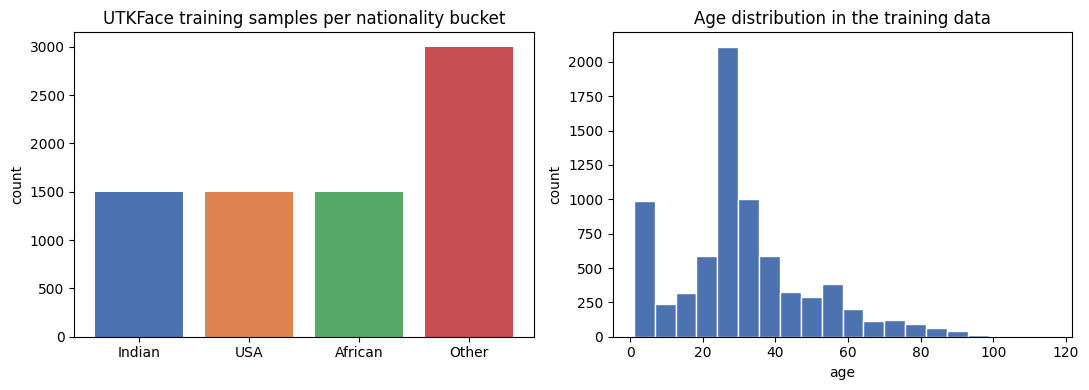

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bucket_counts = [int((y_nationality == i).sum()) for i in range(4)]
axes[0].bar(NATIONALITY_CLASSES, bucket_counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[0].set_title('UTKFace training samples per nationality bucket')
axes[0].set_ylabel('count')

axes[1].hist(y_age, bins=20, color='#4C72B0', edgecolor='white')
axes[1].set_title('Age distribution in the training data')
axes[1].set_xlabel('age')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

In [9]:
nationality_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Conv2D(32, 3, activation='relu', padding='same')(nationality_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

nationality_output = layers.Dense(4, activation='softmax', name='nationality')(x)
age_output = layers.Dense(1, activation='linear', name='age')(x)

nationality_age_model = models.Model(inputs=nationality_input, outputs=[nationality_output, age_output])
nationality_age_model.compile(
    optimizer='adam',
    loss={'nationality': 'sparse_categorical_crossentropy', 'age': 'mse'},
    metrics={'nationality': 'accuracy', 'age': 'mae'}
)

history = nationality_age_model.fit(
    X_train_nat, {'nationality': y_train_nat, 'age': y_train_age},
    validation_data=(X_val_nat, {'nationality': y_val_nat, 'age': y_val_age}),
    epochs=10,
    batch_size=32,
    verbose=1
)

I0000 00:00:1788958078.771800    1093 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788958078.773920    1093 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10
 18/200 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - age_loss: 35.5647 - age_mae: 3.4753 - loss: 38.0290 - nationality_accuracy: 0.3437 - nationality_loss: 2.4644

I0000 00:00:1788958087.667405    1164 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - age_loss: 1.4873 - age_mae: 0.3888 - loss: 2.8090 - nationality_accuracy: 0.4325 - nationality_loss: 1.3159 - val_age_loss: 8.4152 - val_age_mae: 2.4454 - val_loss: 13.0137 - val_nationality_accuracy: 0.3529 - val_nationality_loss: 4.4439
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - age_loss: 0.0706 - age_mae: 0.2065 - loss: 1.1938 - nationality_accuracy: 0.5115 - nationality_loss: 1.1236 - val_age_loss: 2.7862 - val_age_mae: 1.0079 - val_loss: 4.6036 - val_nationality_accuracy: 0.4213 - val_nationality_loss: 1.7455
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - age_loss: 0.0632 - age_mae: 0.1929 - loss: 1.0394 - nationality_accuracy: 0.5675 - nationality_loss: 0.9771 - val_age_loss: 0.0418 - val_age_mae: 0.1595 - val_loss: 0.9623 - val_nationality_accuracy: 0.6204 - val_nationality_loss: 0.9147
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - age_loss: 0.0541 - age_mae: 0.1795 - loss: 0.9675 - nationality_accuracy: 0.61

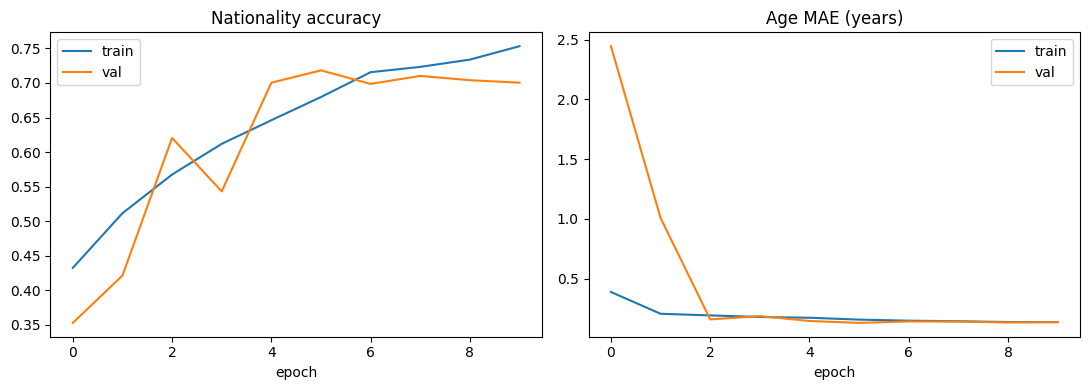

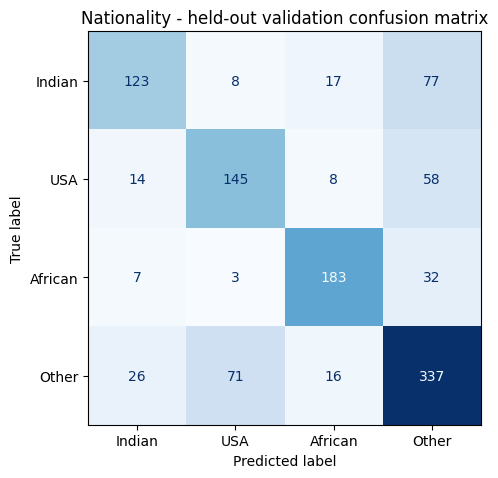

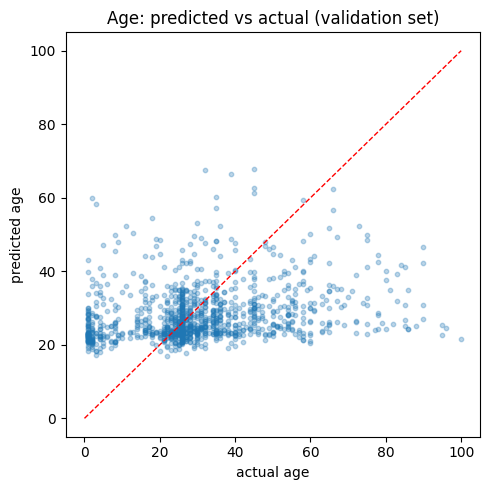

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history['nationality_accuracy'], label='train')
axes[0].plot(history.history['val_nationality_accuracy'], label='val')
axes[0].set_title('Nationality accuracy')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history.history['age_mae'], label='train')
axes[1].plot(history.history['val_age_mae'], label='val')
axes[1].set_title('Age MAE (years)')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

val_nat_preds, val_age_preds = nationality_age_model.predict(X_val_nat, verbose=0)
val_nat_pred_labels = np.argmax(val_nat_preds, axis=1)

cm = confusion_matrix(y_val_nat, val_nat_pred_labels, labels=range(4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=NATIONALITY_CLASSES)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Nationality - held-out validation confusion matrix')
plt.tight_layout()
plt.show()

actual_ages = y_val_age * 100
predicted_ages = val_age_preds.flatten() * 100

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(actual_ages, predicted_ages, alpha=0.3, s=10)
ax.plot([0, 100], [0, 100], 'r--', linewidth=1)  
ax.set_xlabel('actual age')
ax.set_ylabel('predicted age')
ax.set_title('Age: predicted vs actual (validation set)')
plt.tight_layout()
plt.show()

## Build the Emotion model (trained on FER2013)

In [11]:
EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

FER2013_ROOT = find_dataset_root('fer2013', MANUAL_FER2013_ROOT)
print('using fer2013 dataset root:', FER2013_ROOT)

def find_fer2013_train_dir():
    if FER2013_ROOT is None:
        return None
    candidates = glob.glob(os.path.join(FER2013_ROOT, '**', 'train'), recursive=True)
    candidates = [c for c in candidates if os.path.isdir(c) and any(
        os.path.isdir(os.path.join(c, sub)) for sub in os.listdir(c)
    )]
    return candidates[0] if candidates else None

def find_fer2013_csv():
    if FER2013_ROOT is None:
        return None
    candidates = glob.glob(os.path.join(FER2013_ROOT, '**', 'fer2013*.csv'), recursive=True)
    return candidates[0] if candidates else None

MAX_PER_EMOTION = 4000  

def load_fer2013_from_folders(train_dir, max_per_emotion=MAX_PER_EMOTION):
    images, labels = [], []
    for emotion_idx, emotion_name in enumerate(EMOTION_CLASSES):
        emotion_path = os.path.join(train_dir, emotion_name)
        if not os.path.isdir(emotion_path):
            continue
        files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.jpg', '.png'))][:max_per_emotion]
        for fname in files:
            img = Image.open(os.path.join(emotion_path, fname)).convert('L').resize((48, 48))
            images.append(np.array(img))
            labels.append(emotion_idx)
    return np.array(images), np.array(labels)

def load_fer2013_from_csv(csv_path, max_per_emotion=MAX_PER_EMOTION):
    df = pd.read_csv(csv_path)
    if 'Usage' in df.columns:
        df = df[df['Usage'] == 'Training'] 
    images, labels = [], []
    for emotion_id, group in df.groupby('emotion'):
        for pixel_str in group['pixels'].head(max_per_emotion):
            pixels = np.array(pixel_str.split(), dtype=np.uint8).reshape(48, 48)
            images.append(pixels)
            labels.append(emotion_id)
    return np.array(images), np.array(labels)

if FER2013_ROOT is None:
    raise RuntimeError('fer2013 dataset not found - make sure it is attached to the notebook')

fer_train_dir = find_fer2013_train_dir()
if fer_train_dir:
    print('loading fer2013 training images from folders:', fer_train_dir)
    X_emo, y_emo = load_fer2013_from_folders(fer_train_dir)
else:
    fer_csv = find_fer2013_csv()
    print('loading fer2013 training images from csv:', fer_csv)
    X_emo, y_emo = load_fer2013_from_csv(fer_csv)

print(f'loaded {len(X_emo)} fer2013 images for training')

raw_counts = {EMOTION_CLASSES[i]: int((y_emo == i).sum()) for i in range(len(EMOTION_CLASSES))}
lowest_emotion = min(raw_counts, key=raw_counts.get)
print('samples per emotion:', raw_counts)
print(f'lowest: "{lowest_emotion}" with {raw_counts[lowest_emotion]} samples')

X_emo = X_emo.reshape(-1, 48, 48, 1) / 255.0

X_train_emo, X_val_emo, y_train_emo, y_val_emo = train_test_split(
    X_emo, y_emo, test_size=0.15, random_state=42, stratify=y_emo
)
print(f'train: {len(X_train_emo)}, val: {len(X_val_emo)}')

using fer2013 dataset root: /kaggle/input/datasets/deadskull7/fer2013
loading fer2013 training images from csv: /kaggle/input/datasets/deadskull7/fer2013/fer2013.csv
loaded 23602 fer2013 images for training
samples per emotion: {'angry': 3995, 'disgust': 436, 'fear': 4000, 'happy': 4000, 'sad': 4000, 'surprise': 3171, 'neutral': 4000}
lowest: "disgust" with 436 samples
train: 20061, val: 3541


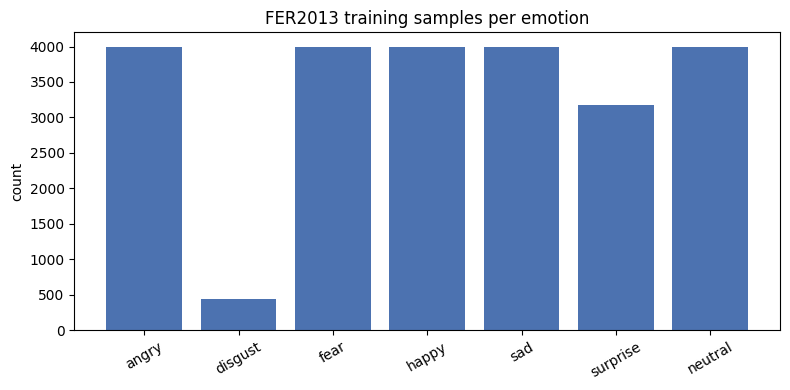

In [12]:
emotion_counts = [int((y_emo == i).sum()) for i in range(len(EMOTION_CLASSES))]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(EMOTION_CLASSES, emotion_counts, color='#4C72B0')
ax.set_title('FER2013 training samples per emotion')
ax.set_ylabel('count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
emotion_model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(EMOTION_CLASSES), activation='softmax')
])

emotion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

emotion_history = emotion_model.fit(
    X_train_emo, y_train_emo,
    validation_data=(X_val_emo, y_val_emo),
    epochs=25,
    batch_size=64,
    verbose=1
)

Epoch 1/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.2600 - loss: 1.8719 - val_accuracy: 0.2361 - val_loss: 2.0442
Epoch 2/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3545 - loss: 1.6002 - val_accuracy: 0.3016 - val_loss: 1.6790
Epoch 3/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3983 - loss: 1.5095 - val_accuracy: 0.4403 - val_loss: 1.4339
Epoch 4/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4352 - loss: 1.4222 - val_accuracy: 0.4174 - val_loss: 1.4492
Epoch 5/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4652 - loss: 1.3590 - val_accuracy: 0.4702 - val_loss: 1.3644
Epoch 6/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4935 - loss: 1.2855 - val_accuracy: 0.4713 - val_loss: 1.3498
Epoch 7/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5204 - loss: 1.2182 - val_accuracy: 0.4948 - val_loss: 1.3165
Epoch 8/25
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5555 - loss: 1.1423 - val_accuracy: 

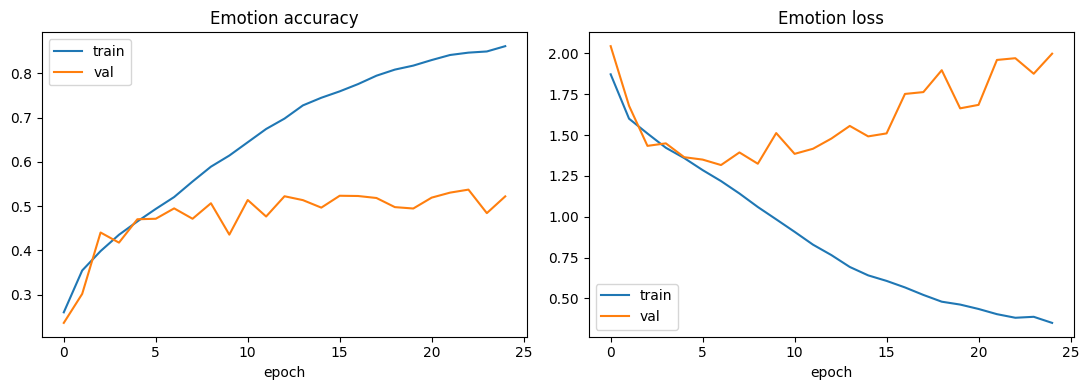

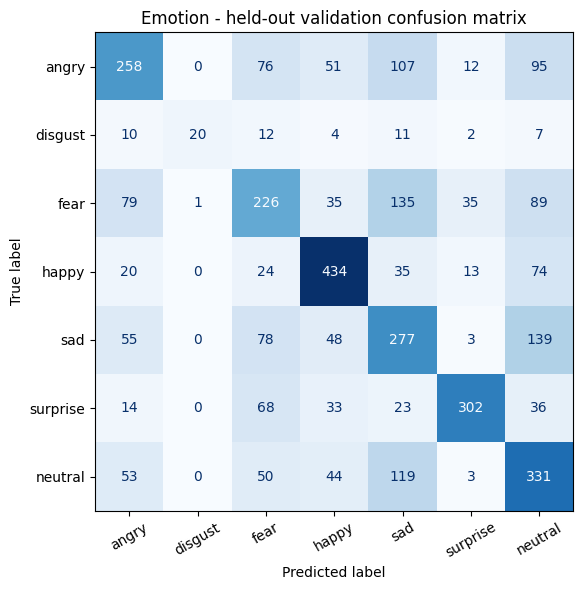

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(emotion_history.history['accuracy'], label='train')
axes[0].plot(emotion_history.history['val_accuracy'], label='val')
axes[0].set_title('Emotion accuracy')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(emotion_history.history['loss'], label='train')
axes[1].plot(emotion_history.history['val_loss'], label='val')
axes[1].set_title('Emotion loss')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

val_emo_preds = np.argmax(emotion_model.predict(X_val_emo, verbose=0), axis=1)
cm = confusion_matrix(y_val_emo, val_emo_preds, labels=range(len(EMOTION_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=EMOTION_CLASSES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
ax.set_title('Emotion - held-out validation confusion matrix')
plt.tight_layout()
plt.show()

## Prediction Function

In [15]:
def predict_all(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print('could not read image, something wrong with the file')
        return None

    face_box = detect_face_box(img)
    if face_box is not None:
        x, y, w, h = face_box
        face_crop = img[y:y + h, x:x + w]
    else:
        face_crop = img  

    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

    nat_input = cv2.resize(face_rgb, (IMG_SIZE, IMG_SIZE)) / 255.0
    nat_probs, age_pred = nationality_age_model.predict(np.expand_dims(nat_input, axis=0), verbose=0)
    nationality = NATIONALITY_CLASSES[np.argmax(nat_probs[0])]
    age = int(round(age_pred[0][0] * 100))

    face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
    emo_input = cv2.resize(face_gray, (48, 48)).reshape(48, 48, 1) / 255.0
    emo_probs = emotion_model.predict(np.expand_dims(emo_input, axis=0), verbose=0)
    emotion = EMOTION_CLASSES[np.argmax(emo_probs[0])]

    result = {}
    result['Nationality'] = nationality
    result['Emotion'] = emotion

    if nationality == 'Indian':
        result['Age'] = age
        result['Dress Colour'] = get_dress_color(img, face_box)
    elif nationality == 'USA':
        result['Age'] = age
    elif nationality == 'African':
        result['Dress Colour'] = get_dress_color(img, face_box)
        
    return result

## Spot-check one sample image per race bucket (UTKFace)

saved samples to: /kaggle/working/utkface_samples


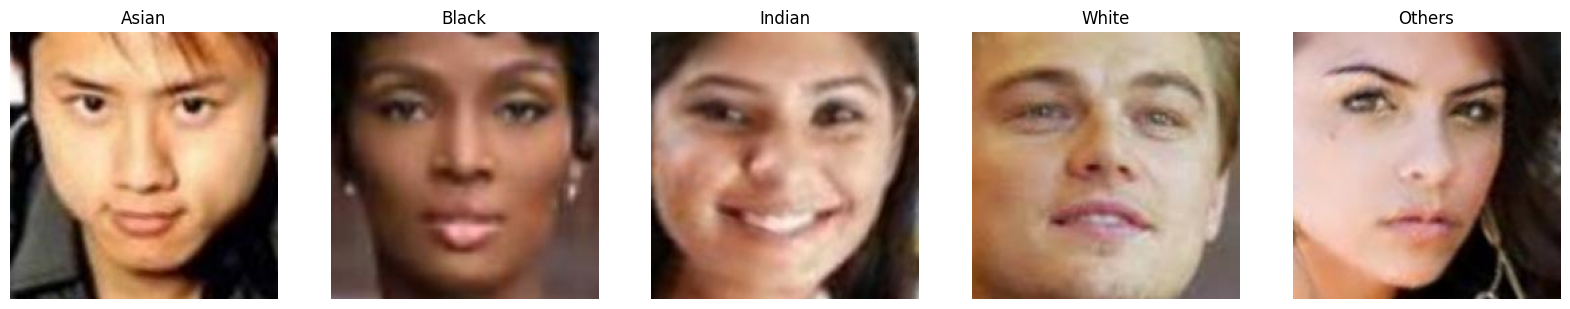

In [16]:
RACE_LABELS = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}

def get_one_image_per_race(folder, n_per_race=1):
    picked = {}
    for fname in os.listdir(folder):
        if not fname.endswith('.jpg'):
            continue
        parts = fname.split('_')
        if len(parts) < 4:
            continue  
        try:
            race_id = int(parts[2])
        except ValueError:
            continue
        race_name = RACE_LABELS.get(race_id, 'Unknown')
        picked.setdefault(race_name, []).append(os.path.join(folder, fname))
        if len(picked) == len(RACE_LABELS) and all(len(v) >= n_per_race for v in picked.values()):
            break
    return {race: paths[:n_per_race] for race, paths in picked.items()}

sample_images = get_one_image_per_race(UTKFACE_DIR)

UTK_SAMPLE_SIZE = (200, 200)

UTK_SAMPLES_DIR = '/kaggle/working/utkface_samples'
os.makedirs(UTK_SAMPLES_DIR, exist_ok=True)
for race, paths in sample_images.items():
    img = Image.open(paths[0]).convert('RGB').resize(UTK_SAMPLE_SIZE)
    img.save(os.path.join(UTK_SAMPLES_DIR, f'{race}.jpg'))
print('saved samples to:', UTK_SAMPLES_DIR)

fig, axes = plt.subplots(1, len(sample_images), figsize=(4 * len(sample_images), 4))
for ax, (race, paths) in zip(axes, sample_images.items()):
    img = Image.open(paths[0])
    ax.imshow(img)
    ax.set_title(race)
    ax.axis('off')
plt.show()

## Real emotion accuracy on a held-out FER2013 test set

In [17]:
val_loss, val_acc = emotion_model.evaluate(X_val_emo, y_val_emo, verbose=0)
print(f'held-out validation accuracy: {val_acc * 100:.1f}%')

held-out validation accuracy: 52.2%


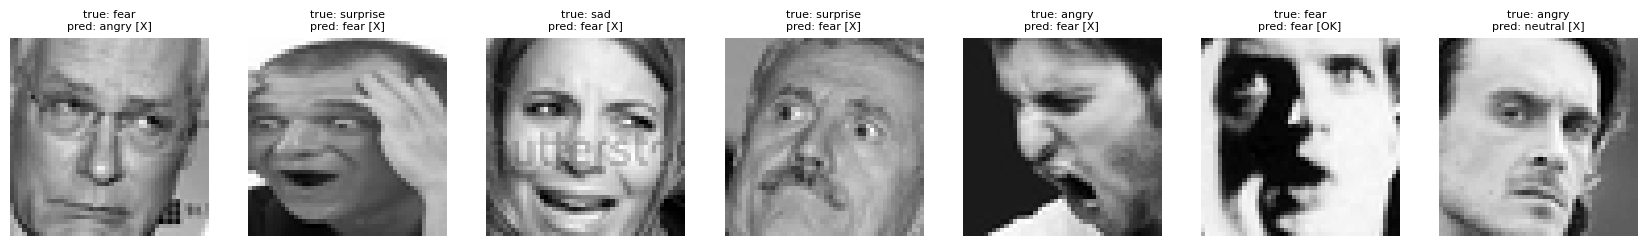

In [18]:
sample_idx = np.random.choice(len(X_val_emo), size=7, replace=False)

fig, axes = plt.subplots(1, len(sample_idx), figsize=(3 * len(sample_idx), 3))
for ax, i in zip(axes, sample_idx):
    pred = EMOTION_CLASSES[np.argmax(emotion_model.predict(X_val_emo[i:i + 1], verbose=0)[0])]
    true = EMOTION_CLASSES[y_val_emo[i]]
    match = 'OK' if pred == true else 'X'
    ax.imshow(X_val_emo[i].reshape(48, 48), cmap='gray')
    ax.set_title(f'true: {true}\npred: {pred} [{match}]', fontsize=8)
    ax.axis('off')
plt.show()

## Test nationality mapping using FairFace 

using fairface dataset root: /kaggle/input/datasets/aibloy/fairface/FairFace
found fairface csv: /kaggle/input/datasets/aibloy/fairface/FairFace/train_labels.csv
resolved 7/7 fairface sample images


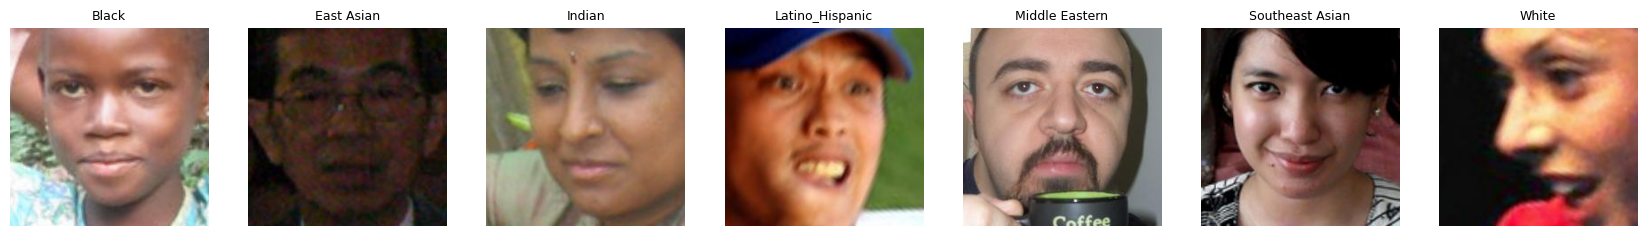

In [19]:
FAIRFACE_TO_EXPECTED_NATIONALITY = {
    'Indian': 'Indian',
    'Black': 'African',
    'White': 'USA',
    'East Asian': 'Other',
    'Southeast Asian': 'Other',
    'Latino_Hispanic': 'Other',
    'Middle Eastern': 'Other',
}

FAIRFACE_ROOT = find_dataset_root('fairface', MANUAL_FAIRFACE_ROOT)
print('using fairface dataset root:', FAIRFACE_ROOT)

def find_fairface_csv():
    if FAIRFACE_ROOT is None:
        return None

    for filename in ('fairface_label_train.csv', 'train_labels.csv'):
        candidates = glob.glob(os.path.join(FAIRFACE_ROOT, '**', filename), recursive=True)
        if candidates:
            return candidates[0]

    candidates = glob.glob(os.path.join(FAIRFACE_ROOT, '**', '*train*.csv'), recursive=True)
    return candidates[0] if candidates else None

fairface_csv = find_fairface_csv()

if fairface_csv is None:
    print('could not find a fairface train csv - is the dataset attached? check /kaggle/input/')
else:
    print('found fairface csv:', fairface_csv)
    fairface_base_dir = os.path.dirname(fairface_csv)
    search_roots = [fairface_base_dir, os.path.dirname(fairface_base_dir), FAIRFACE_ROOT]

    df_ff = pd.read_csv(fairface_csv)

    fairface_samples = {}
    for race, group in df_ff.groupby('race'):
        for rel_path in group['file'].head(5):
            found_path = None
            for root in search_roots:
                candidate = os.path.join(root, rel_path)
                if os.path.exists(candidate):
                    found_path = candidate
                    break
            if found_path is None:
                matches = glob.glob(os.path.join(FAIRFACE_ROOT, '**', os.path.basename(rel_path)), recursive=True)
                if matches:
                    found_path = matches[0]
            if found_path:
                fairface_samples[race] = found_path
                break

    print(f'resolved {len(fairface_samples)}/{df_ff["race"].nunique()} fairface sample images')

    FAIRFACE_SAMPLES_DIR = '/kaggle/working/fairface_samples'
    os.makedirs(FAIRFACE_SAMPLES_DIR, exist_ok=True)
    for race, path in fairface_samples.items():
        img = Image.open(path).convert('RGB').resize((200, 200))
        safe_name = race.replace(' ', '_')
        img.save(os.path.join(FAIRFACE_SAMPLES_DIR, f'{safe_name}.jpg'))

    fig, axes = plt.subplots(1, len(fairface_samples), figsize=(3 * len(fairface_samples), 3))
    if len(fairface_samples) == 1:
        axes = [axes]
    for ax, (race, path) in zip(axes, fairface_samples.items()):
        ax.imshow(Image.open(path))
        ax.set_title(race, fontsize=9)
        ax.axis('off')
    plt.show()

===== ACCURACY SUMMARY =====
Nationality (held-out UTKFace val):   70.0%
Age MAE     (held-out UTKFace val):   13.6 years
Emotion     (held-out FER2013 val):   52.2%
Nationality (FairFace, independent):  28.6% (2/7)
Fashion colour classification (held-out):  41.5% (54/130)


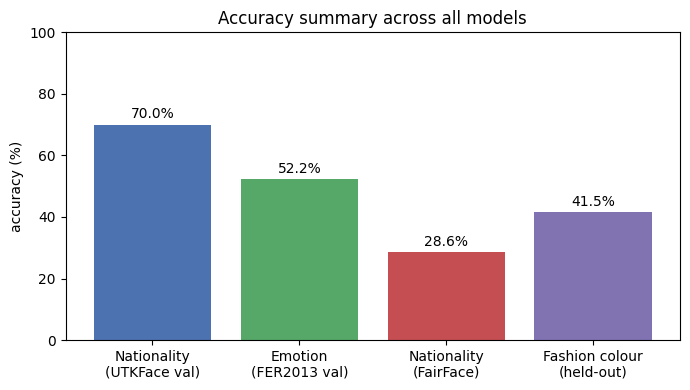

In [22]:
nat_eval = nationality_age_model.evaluate(X_val_nat, {'nationality': y_val_nat, 'age': y_val_age}, verbose=0, return_dict=True)
nationality_accuracy = nat_eval['nationality_accuracy']
age_mae_years = nat_eval['age_mae'] * 100  # undo the /100 normalization from training

emo_eval = emotion_model.evaluate(X_val_emo, y_val_emo, verbose=0, return_dict=True)
emotion_accuracy = emo_eval['accuracy']

# fairface is the genuinely independent test - reusing the samples step 5d already
# resolved instead of re-downloading/re-resolving anything
if 'fairface_samples' in globals() and fairface_samples:
    fairface_correct = 0
    for race, path in fairface_samples.items():
        expected = FAIRFACE_TO_EXPECTED_NATIONALITY.get(race, 'Other')
        res = predict_all(path)
        predicted = res['Nationality'] if res else 'ERROR'
        if predicted == expected:
            fairface_correct += 1
    fairface_accuracy = fairface_correct / len(fairface_samples)
    fairface_label = f'{fairface_correct}/{len(fairface_samples)}'
else:
    fairface_accuracy = None
    fairface_label = 'not available'


# fashion product images dataset - test colour classification on held-out
# samples NOT used when building COLOR_NAMES (which used the first
# n_per_colour images per baseColour category), checking whether they land
# back in the same main colour family as their true label
FASHION_TEST_PER_COLOUR = 3
FASHION_BUILD_PER_COLOUR = 10  # matches n_per_colour used when COLOR_NAMES was built

fashion_colour_accuracy = None
if FASHION_ROOT is not None and COLOR_NAMES:
    fashion_styles_path = find_fashion_styles_csv()
    fashion_images_dir = find_fashion_images_dir()
    if fashion_styles_path and fashion_images_dir:
        df_fashion_test = pd.read_csv(fashion_styles_path, on_bad_lines='skip')

        fashion_correct = 0
        fashion_total = 0
        for colour_name, group in df_fashion_test.groupby('baseColour'):
            colour_name = str(colour_name)
            if colour_name not in COLOR_NAMES:
                continue
            true_main_bucket = classify_main_color(COLOR_NAMES[colour_name])

            held_out_ids = group['id'].iloc[FASHION_BUILD_PER_COLOUR:FASHION_BUILD_PER_COLOUR + FASHION_TEST_PER_COLOUR]
            for pid in held_out_ids:
                img_path = os.path.join(fashion_images_dir, f'{pid}.jpg')
                if not os.path.exists(img_path):
                    continue
                img = Image.open(img_path).convert('RGB').resize((50, 50))
                arr = np.array(img)
                crop_margin = int(50 * 0.2)
                arr = arr[crop_margin:50 - crop_margin, crop_margin:50 - crop_margin]
                avg_rgb = arr.reshape(-1, 3).mean(axis=0)
                predicted_main_bucket = classify_main_color(avg_rgb)

                fashion_total += 1
                if predicted_main_bucket == true_main_bucket:
                    fashion_correct += 1

        if fashion_total:
            fashion_colour_accuracy = fashion_correct / fashion_total
            fashion_colour_label = f'{fashion_correct}/{fashion_total}'

print('===== ACCURACY SUMMARY =====')
print(f'Nationality (held-out UTKFace val):   {nationality_accuracy * 100:.1f}%')
print(f'Age MAE     (held-out UTKFace val):   {age_mae_years:.1f} years')
print(f'Emotion     (held-out FER2013 val):   {emotion_accuracy * 100:.1f}%')
if fairface_accuracy is not None:
    print(f'Nationality (FairFace, independent):  {fairface_accuracy * 100:.1f}% ({fairface_label})')
if fashion_colour_accuracy is not None:
    print(f'Fashion colour classification (held-out):  {fashion_colour_accuracy * 100:.1f}% ({fashion_colour_label})')

labels = ['Nationality\n(UTKFace val)', 'Emotion\n(FER2013 val)']
values = [nationality_accuracy * 100, emotion_accuracy * 100]
colors = ['#4C72B0', '#55A868']
if fairface_accuracy is not None:
    labels.append('Nationality\n(FairFace)')
    values.append(fairface_accuracy * 100)
    colors.append('#C44E52')
if fashion_colour_accuracy is not None:
    labels.append('Fashion colour\n(held-out)')
    values.append(fashion_colour_accuracy * 100)
    colors.append('#8172B2')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, values, color=colors)
ax.set_ylabel('accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Accuracy summary across all models')
for i, v in enumerate(values):
    ax.text(i, v + 2, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

## GUI

In [23]:
def predict_gui(image_path):

    if image_path is None:
        return 'Upload an image first!'

    res = predict_all(image_path)
    if res is None:
        return 'Could not process this image :('

    return '\n'.join(f'{key}: {val}' for key, val in res.items())

demo = gr.Interface(
    fn=predict_gui,
    inputs=gr.Image(type='filepath', label='image_path', height=350, width=450),
    outputs=gr.Textbox(label='Prediction', lines=8),
    title='Nationality + Emotion Detector',
    description='Upload a photo of a person. Predicts nationality + emotion always, and adds age/dress colour depending on nationality (see rules at the top of the notebook).'
)

demo.launch(share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8b695fa1bbfdced6ab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8b695fa1bbfdced6ab.gradio.live


In [24]:
demo.close()

Closing server running on port: 7860


## Results

- Both models are tested on data they never saw during training (not the training images).
- **Nationality + Age model**: tested on held-out UTKFace data, and separately on FairFace (a completely different dataset). The FairFace score matters more — it shows whether the model actually generalizes, not just memorizes UTKFace.
- **Emotion model**: tested on held-out FER2013 data.
- **Dress colour**: tested on held-out Fashion Product Images samples not used to build the colour list.
- What's measured: accuracy/loss curves, confusion matrices, and an age scatter plot.
- Exact numbers shift slightly each run — check the Accuracy Summary cell for the current results.

## Conclusion

- Built a full pipeline: data prep, two CNNs (nationality+age, emotion), a colour-detection heuristic, evaluation, and a Gradio interface.
- Both CNNs are trained from scratch — no pretrained model was compared against them in this version.
- That comparison is listed under Future Improvements, not something this version already does.

## Limitations

- Nationality can't really be predicted from a face — it's approximated from ethnicity labels, not a real nationality detector.
- The White → USA mapping is weak — most white people aren't American, and plenty of Americans aren't white.
- "African" is a continent, not an ethnicity — same problem as above.
- Both models are trained on a limited subset of data and epochs to save time, which caps their accuracy.
- FER2013 has imbalanced classes (e.g. "disgust" has very few images), which can bias the emotion model.
- Dress colour is a simple heuristic — it only works when clothing is actually visible in the photo.
- Treat all predictions as demo output, not real judgments about a person.

## Future Improvements

- Train on the full datasets with more epochs.
- Compare against a pretrained model (transfer learning).
- Fix FER2013's class imbalance properly.
- Improve dress colour detection with real clothing segmentation.
- Test on more varied real-world photos.
- Add better error handling to the Gradio interface.